# 67. The Kitting & Value-Added Service Scheduling Problem
## Tier 1: The Pen & Paper Method (Mathematical Formulation)

### Key Assumptions
- Multiple kit types can be assembled across different shifts
- Demand is known for each planning period
- Limited capacity per shift based on labor and equipment constraints
- Inventory holding costs apply to both individual SKUs and finished kits
- Shortages are allowed but incur penalty costs

### Approach (Step-by-Step)
1. **Define Decision Variables**: Quantities of each kit to produce in each shift/period
2. **Formulate Objective Function**: Minimize total costs (production + inventory + shortage)
3. **Set Up Constraints**: Demand satisfaction, capacity limits, inventory balance
4. **Solve Mixed-Integer Program**: Use pulp solver for optimal solution
5. **Extract and Analyze Results**: Examine production schedule and cost breakdown

### What to Look For in the Results
- Optimal kitting schedule across shifts and periods
- Inventory levels for both kits and individual SKUs
- Capacity utilization in each shift
- Trade-offs between production, inventory, and shortage costs

### Concrete Example (from the source)
We'll implement the example with 2 SKUs, 2 kit types, 2 shifts, and 3 periods:
- Kit 1: 2 units of SKU 1 + 1 unit of SKU 2
- Kit 2: 1 unit of SKU 1 + 3 units of SKU 2
- Processing times: 3 min (Kit 1), 4 min (Kit 2)
- Shift capacities: 480 min (Shift 1), 420 min (Shift 2)

In [1]:
# Import required libraries for mathematical optimization
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Tuple

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
@dataclass
class KittingProblem:
    """Data structure for kitting optimization problem"""
    # Problem dimensions
    num_skus: int
    num_kits: int
    num_shifts: int
    num_periods: int
    
    # Parameters
    demand: np.ndarray  # [kit][period]
    processing_time: np.ndarray  # [kit]
    holding_cost_sku: np.ndarray  # [sku][period]
    holding_cost_kit: np.ndarray  # [kit][period]
    labor_cost: np.ndarray  # [shift][period]
    capacity: np.ndarray  # [shift][period]
    bill_of_materials: np.ndarray  # [sku][kit]
    shortage_penalty: float = 10.0
    storage_capacity: float = 1000.0

# Initialize the concrete example from the source
def create_example_problem():
    """Create the example problem from the source material"""
    return KittingProblem(
        num_skus=2,
        num_kits=2,
        num_shifts=2,
        num_periods=3,
        
        # Demand for each kit across periods
        demand=np.array([
            [100, 90, 80],  # Kit 1 demand
            [50, 60, 40]    # Kit 2 demand
        ]),
        
        # Processing time per kit (minutes)
        processing_time=np.array([3, 4]),
        
        # Holding costs per SKU per period ($)
        holding_cost_sku=np.array([
            [0.50, 0.50, 0.50],  # SKU 1
            [0.50, 0.50, 0.50]   # SKU 2
        ]),
        
        # Holding costs per kit per period ($)
        holding_cost_kit=np.array([
            [0.80, 0.80, 0.80],  # Kit 1
            [1.00, 1.00, 1.00]   # Kit 2
        ]),
        
        # Labor cost per shift per period ($/hour)
        labor_cost=np.array([
            [15.0, 15.0, 15.0],  # Shift 1
            [18.0, 18.0, 18.0]   # Shift 2
        ]),
        
        # Available capacity per shift per period (minutes)
        capacity=np.array([
            [480, 480, 480],  # Shift 1
            [420, 420, 420]   # Shift 2
        ]),
        
        # Bill of materials: SKU requirements per kit
        bill_of_materials=np.array([
            [2, 1],  # SKU 1: 2 for Kit 1, 1 for Kit 2
            [1, 3]   # SKU 2: 1 for Kit 1, 3 for Kit 2
        ]),
        
        shortage_penalty=10.0,
        storage_capacity=1000.0
    )

# Create the problem instance
problem = create_example_problem()
print(f"Problem created: {problem.num_kits} kits, {problem.num_skus} SKUs, {problem.num_shifts} shifts, {problem.num_periods} periods")

Problem created: 2 kits, 2 SKUs, 2 shifts, 3 periods


In [3]:
def solve_kitting_mip(problem: KittingProblem) -> Dict:
    """Solve the kitting problem using mixed-integer programming"""
    
    # Create the optimization problem
    model = pulp.LpProblem("Kitting_Scheduling", pulp.LpMinimize)
    
    # Decision variables
    # x[k][s][t] = quantity of kit k produced in shift s during period t
    x = {}
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                x[(k, s, t)] = pulp.LpVariable(f"x_{k}_{s}_{t}", lowBound=0, cat='Integer')
    
    # y[k][s][t] = binary: 1 if kit k is produced in shift s during period t
    y = {}
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                y[(k, s, t)] = pulp.LpVariable(f"y_{k}_{s}_{t}", cat='Binary')
    
    # inv[k][t] = inventory level of kit k at end of period t
    inv_kit = {}
    for k in range(problem.num_kits):
        for t in range(problem.num_periods):
            inv_kit[(k, t)] = pulp.LpVariable(f"inv_kit_{k}_{t}", lowBound=0, cat='Continuous')
    
    # inv_sku[i][t] = inventory level of SKU i at end of period t
    inv_sku = {}
    for i in range(problem.num_skus):
        for t in range(problem.num_periods):
            inv_sku[(i, t)] = pulp.LpVariable(f"inv_sku_{i}_{t}", lowBound=0, cat='Continuous')
    
    # short[k][t] = shortage of kit k in period t
    short = {}
    for k in range(problem.num_kits):
        for t in range(problem.num_periods):
            short[(k, t)] = pulp.LpVariable(f"short_{k}_{t}", lowBound=0, cat='Continuous')
    
    # Objective function: minimize total costs
    production_cost = pulp.lpSum([
        (problem.labor_cost[s, t] / 60) * problem.processing_time[k] * x[(k, s, t)]
        for k in range(problem.num_kits)
        for s in range(problem.num_shifts)
        for t in range(problem.num_periods)
    ])
    
    inventory_cost_kit = pulp.lpSum([
        problem.holding_cost_kit[k, t] * inv_kit[(k, t)]
        for k in range(problem.num_kits)
        for t in range(problem.num_periods)
    ])
    
    inventory_cost_sku = pulp.lpSum([
        problem.holding_cost_sku[i, t] * inv_sku[(i, t)]
        for i in range(problem.num_skus)
        for t in range(problem.num_periods)
    ])
    
    shortage_cost = pulp.lpSum([
        problem.shortage_penalty * short[(k, t)]
        for k in range(problem.num_kits)
        for t in range(problem.num_periods)
    ])
    
    model += production_cost + inventory_cost_kit + inventory_cost_sku + shortage_cost
    
    # Constraints
    M = 10000  # Big M for linking constraints
    
    # Demand satisfaction and inventory balance for kits
    for k in range(problem.num_kits):
        for t in range(problem.num_periods):
            if t == 0:
                # First period: starting inventory = 0
                model += pulp.lpSum([x[(k, s, t)] for s in range(problem.num_shifts)]) - problem.demand[k, t] + short[(k, t)] == inv_kit[(k, t)]
            else:
                # Subsequent periods
                model += inv_kit[(k, t-1)] + pulp.lpSum([x[(k, s, t)] for s in range(problem.num_shifts)]) - problem.demand[k, t] + short[(k, t)] == inv_kit[(k, t)]
    
    # Individual SKU inventory balance (assuming sufficient supply)
    for i in range(problem.num_skus):
        for t in range(problem.num_periods):
            sku_consumption = pulp.lpSum([
                problem.bill_of_materials[i, k] * x[(k, s, t)]
                for k in range(problem.num_kits)
                for s in range(problem.num_shifts)
            ])
            # Assume ample supply (500 units per period)
            supply = 500
            if t == 0:
                model += supply - sku_consumption == inv_sku[(i, t)]
            else:
                model += inv_sku[(i, t-1)] + supply - sku_consumption == inv_sku[(i, t)]
    
    # Capacity constraints
    for s in range(problem.num_shifts):
        for t in range(problem.num_periods):
            model += pulp.lpSum([
                problem.processing_time[k] * x[(k, s, t)]
                for k in range(problem.num_kits)
            ]) <= problem.capacity[s, t]
    
    # Storage capacity constraint
    for t in range(problem.num_periods):
        model += pulp.lpSum([inv_kit[(k, t)] for k in range(problem.num_kits)]) <= problem.storage_capacity
    
    # Linking constraints (production quantity to binary setup variable)
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                model += x[(k, s, t)] <= M * y[(k, s, t)]
    
    # Solve the model
    print("Solving MIP optimization...")
    model.solve(pulp.PULP_CBC_CMD(msg=False))
    
    # Extract results
    results = {
        'status': pulp.LpStatus[model.status],
        'objective': pulp.value(model.objective),
        'production_schedule': np.zeros((problem.num_kits, problem.num_shifts, problem.num_periods)),
        'kit_inventory': np.zeros((problem.num_kits, problem.num_periods)),
        'sku_inventory': np.zeros((problem.num_skus, problem.num_periods)),
        'shortages': np.zeros((problem.num_kits, problem.num_periods))
    }
    
    # Extract variable values
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                results['production_schedule'][k, s, t] = x[(k, s, t)].varValue
    
    for k in range(problem.num_kits):
        for t in range(problem.num_periods):
            results['kit_inventory'][k, t] = inv_kit[(k, t)].varValue
            results['shortages'][k, t] = short[(k, t)].varValue
    
    for i in range(problem.num_skus):
        for t in range(problem.num_periods):
            results['sku_inventory'][i, t] = inv_sku[(i, t)].varValue
    
    return results, model

# Solve the problem
results, model = solve_kitting_mip(problem)
print(f"Solution status: {results['status']}")
print(f"Total cost: ${results['objective']:.2f}")

Solving MIP optimization...


Solution status: Optimal
Total cost: $1644.00


In [4]:
def analyze_solution(results, problem):
    """Analyze and display the solution results"""
    
    print("=" * 60)
    print("OPTIMAL KITTING SCHEDULE ANALYSIS")
    print("=" * 60)
    
    # Production schedule analysis
    print("\n1. PRODUCTION SCHEDULE (units per shift per period):")
    print("-" * 50)
    
    for k in range(problem.num_kits):
        print(f"\nKit {k+1}:")
        schedule_df = pd.DataFrame(
            results['production_schedule'][k],
            index=[f"Shift {s+1}" for s in range(problem.num_shifts)],
            columns=[f"Period {t+1}" for t in range(problem.num_periods)]
        )
        print(schedule_df.round(1))
        
        # Total production per period
        total_per_period = results['production_schedule'][k].sum(axis=0)
        print(f"Total per period: [{', '.join([f'{x:.1f}' for x in total_per_period])}]")
    
    # Cost breakdown
    print("\n2. COST BREAKDOWN:")
    print("-" * 30)
    
    # Calculate cost components
    production_cost = 0
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                production_cost += (problem.labor_cost[s, t] / 60) * problem.processing_time[k] * results['production_schedule'][k, s, t]
    
    inventory_cost_kit = np.sum(problem.holding_cost_kit * results['kit_inventory'])
    inventory_cost_sku = np.sum(problem.holding_cost_sku * results['sku_inventory'])
    shortage_cost = np.sum(problem.shortage_penalty * results['shortages'])
    
    print(f"Production cost: ${production_cost:.2f}")
    print(f"Kit inventory cost: ${inventory_cost_kit:.2f}")
    print(f"SKU inventory cost: ${inventory_cost_sku:.2f}")
    print(f"Shortage cost: ${shortage_cost:.2f}")
    print(f"Total cost: ${results['objective']:.2f}")
    
    # Capacity utilization
    print("\n3. CAPACITY UTILIZATION:")
    print("-" * 30)
    
    for s in range(problem.num_shifts):
        print(f"\nShift {s+1}:")
        for t in range(problem.num_periods):
            used_capacity = np.sum([
                problem.processing_time[k] * results['production_schedule'][k, s, t]
                for k in range(problem.num_kits)
            ])
            utilization = (used_capacity / problem.capacity[s, t]) * 100
            print(f"  Period {t+1}: {used_capacity:.1f}/{problem.capacity[s, t]} min ({utilization:.1f}%)")
    
    # Service level analysis
    print("\n4. SERVICE LEVEL ANALYSIS:")
    print("-" * 30)
    
    total_demand = np.sum(problem.demand)
    total_shortage = np.sum(results['shortages'])
    service_level = ((total_demand - total_shortage) / total_demand) * 100
    
    print(f"Total demand: {total_demand:.1f} units")
    print(f"Total shortage: {total_shortage:.1f} units")
    print(f"Service level: {service_level:.1f}%")
    
    for k in range(problem.num_kits):
        kit_demand = np.sum(problem.demand[k])
        kit_shortage = np.sum(results['shortages'][k])
        kit_service = ((kit_demand - kit_shortage) / kit_demand) * 100
        print(f"  Kit {k+1}: {kit_service:.1f}% service level")

# Analyze the solution
analyze_solution(results, problem)

OPTIMAL KITTING SCHEDULE ANALYSIS

1. PRODUCTION SCHEDULE (units per shift per period):
--------------------------------------------------

Kit 1:
         Period 1  Period 2  Period 3
Shift 1       0.0       0.0       0.0
Shift 2     140.0     140.0       0.0
Total per period: [140.0, 140.0, 0.0]

Kit 2:
         Period 1  Period 2  Period 3
Shift 1     120.0     120.0       0.0
Shift 2       0.0       0.0       0.0
Total per period: [120.0, 120.0, 0.0]

2. COST BREAKDOWN:
------------------------------
Production cost: $492.00
Kit inventory cost: $402.00
SKU inventory cost: $750.00
Shortage cost: $0.00
Total cost: $1644.00

3. CAPACITY UTILIZATION:
------------------------------

Shift 1:
  Period 1: 480.0/480 min (100.0%)
  Period 2: 480.0/480 min (100.0%)
  Period 3: 0.0/480 min (0.0%)

Shift 2:
  Period 1: 420.0/420 min (100.0%)
  Period 2: 420.0/420 min (100.0%)
  Period 3: 0.0/420 min (0.0%)

4. SERVICE LEVEL ANALYSIS:
------------------------------
Total demand: 420.0 units
Tot

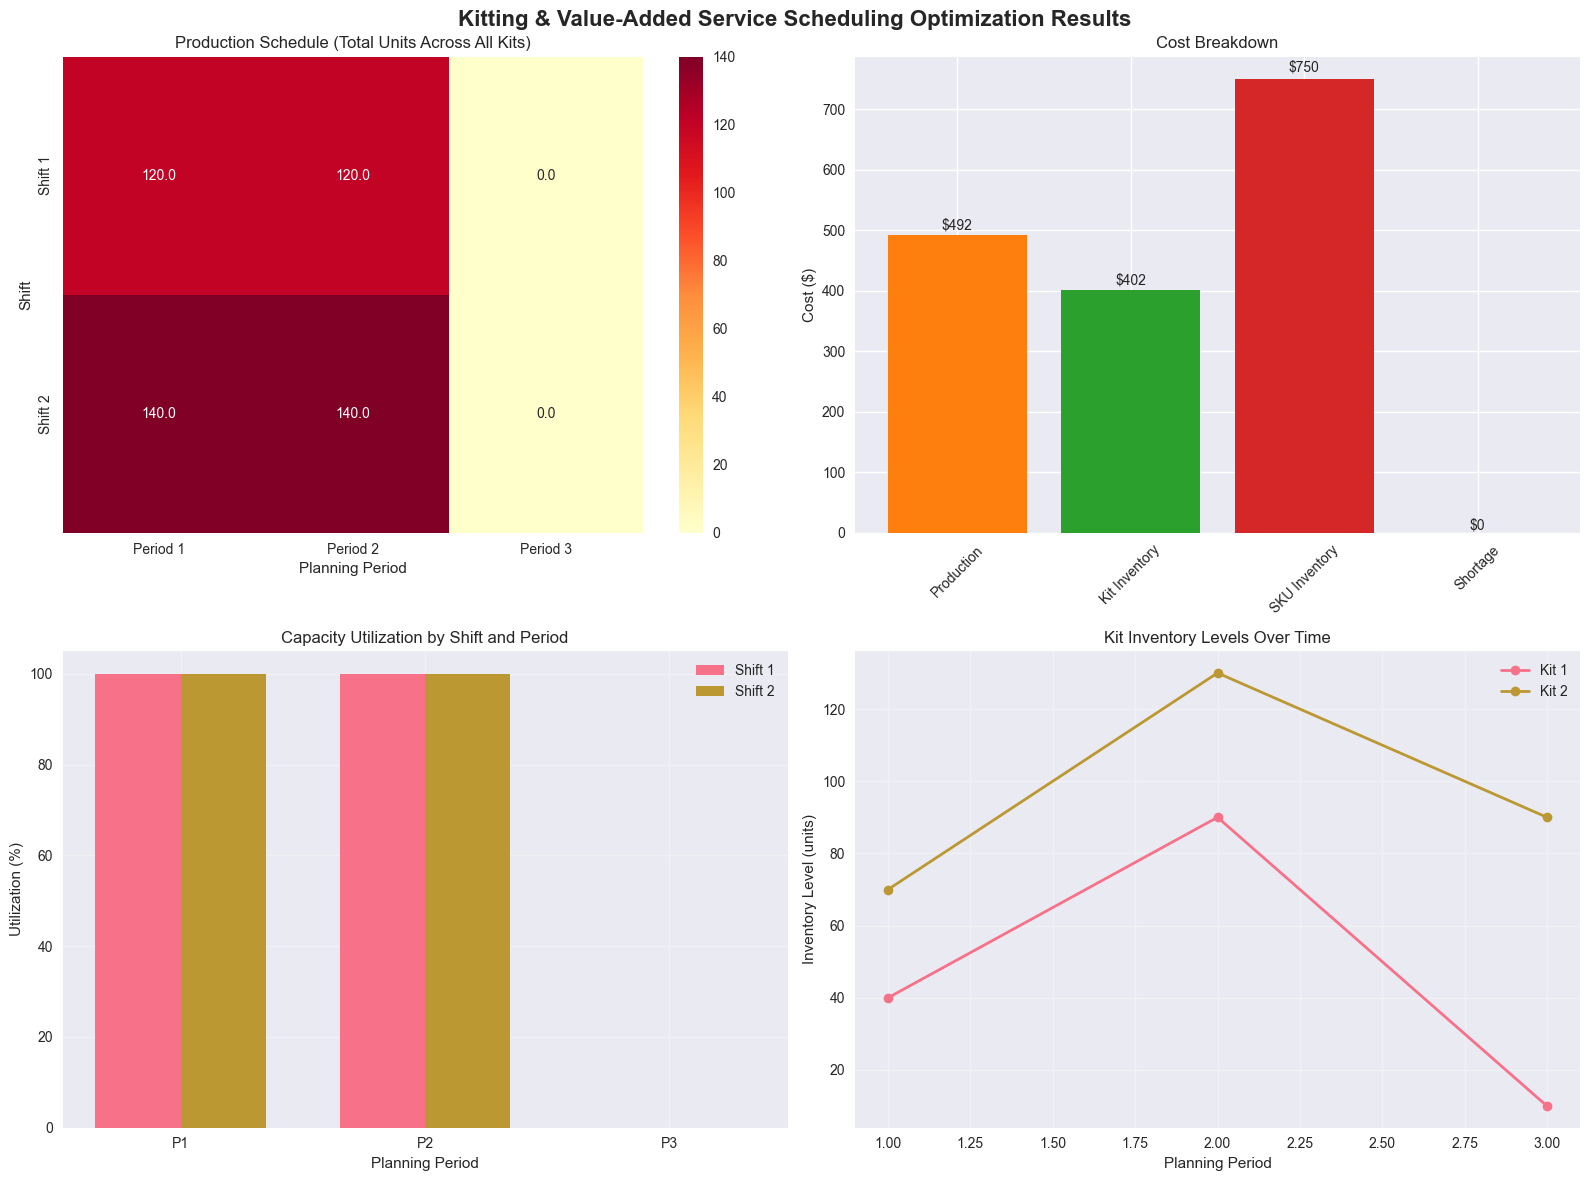

In [5]:
def create_comprehensive_visualization(results, problem):
    """Create comprehensive visualization of the kitting optimization results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Kitting & Value-Added Service Scheduling Optimization Results', fontsize=16, fontweight='bold')
    
    # 1. Production Schedule Heatmap
    ax1 = axes[0, 0]
    
    # Combine all kits for visualization
    total_production = results['production_schedule'].sum(axis=0)  # Sum across kits
    
    sns.heatmap(total_production, 
                annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=[f'Period {t+1}' for t in range(problem.num_periods)],
                yticklabels=[f'Shift {s+1}' for s in range(problem.num_shifts)],
                ax=ax1)
    ax1.set_title('Production Schedule (Total Units Across All Kits)')
    ax1.set_xlabel('Planning Period')
    ax1.set_ylabel('Shift')
    
    # 2. Cost Breakdown
    ax2 = axes[0, 1]
    
    # Calculate cost components
    production_cost = 0
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                production_cost += (problem.labor_cost[s, t] / 60) * problem.processing_time[k] * results['production_schedule'][k, s, t]
    
    inventory_cost_kit = np.sum(problem.holding_cost_kit * results['kit_inventory'])
    inventory_cost_sku = np.sum(problem.holding_cost_sku * results['sku_inventory'])
    shortage_cost = np.sum(problem.shortage_penalty * results['shortages'])
    
    costs = ['Production', 'Kit Inventory', 'SKU Inventory', 'Shortage']
    values = [production_cost, inventory_cost_kit, inventory_cost_sku, shortage_cost]
    colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    bars = ax2.bar(costs, values, color=colors)
    ax2.set_title('Cost Breakdown')
    ax2.set_ylabel('Cost ($)')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'${value:.0f}', ha='center', va='bottom')
    
    # 3. Capacity Utilization
    ax3 = axes[1, 0]
    
    periods = []
    shifts = []
    utilizations = []
    
    for s in range(problem.num_shifts):
        for t in range(problem.num_periods):
            used_capacity = np.sum([
                problem.processing_time[k] * results['production_schedule'][k, s, t]
                for k in range(problem.num_kits)
            ])
            utilization = (used_capacity / problem.capacity[s, t]) * 100
            periods.append(t+1)
            shifts.append(s+1)
            utilizations.append(utilization)
    
    # Create grouped bar chart
    width = 0.35
    x_pos = np.arange(max(periods))
    
    for s in range(problem.num_shifts):
        shift_util = [utilizations[i] for i in range(len(utilizations)) if shifts[i] == s+1]
        ax3.bar(x_pos + width*s, shift_util, width, label=f'Shift {s+1}')
    
    ax3.set_title('Capacity Utilization by Shift and Period')
    ax3.set_xlabel('Planning Period')
    ax3.set_ylabel('Utilization (%)')
    ax3.set_xticks(x_pos + width/2)
    ax3.set_xticklabels([f'P{t+1}' for t in range(problem.num_periods)])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Inventory Levels Over Time
    ax4 = axes[1, 1]
    
    periods_range = range(1, problem.num_periods + 1)
    
    for k in range(problem.num_kits):
        ax4.plot(periods_range, results['kit_inventory'][k], 
                marker='o', linewidth=2, label=f'Kit {k+1}')
    
    ax4.set_title('Kit Inventory Levels Over Time')
    ax4.set_xlabel('Planning Period')
    ax4.set_ylabel('Inventory Level (units)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create comprehensive visualization
fig = create_comprehensive_visualization(results, problem)

SENSITIVITY ANALYSIS
Solving MIP optimization...


Solving MIP optimization...
Solving MIP optimization...



Capacity Scenario Comparison:
--------------------------------------------------
Capacity     Total Cost   Service Level  Total Production
--------------------------------------------------
0.8          $1763.70     100.0        % 486.0          
1.0          $1644.00     100.0        % 520.0          
1.2          $1584.40     100.0        % 600.0          


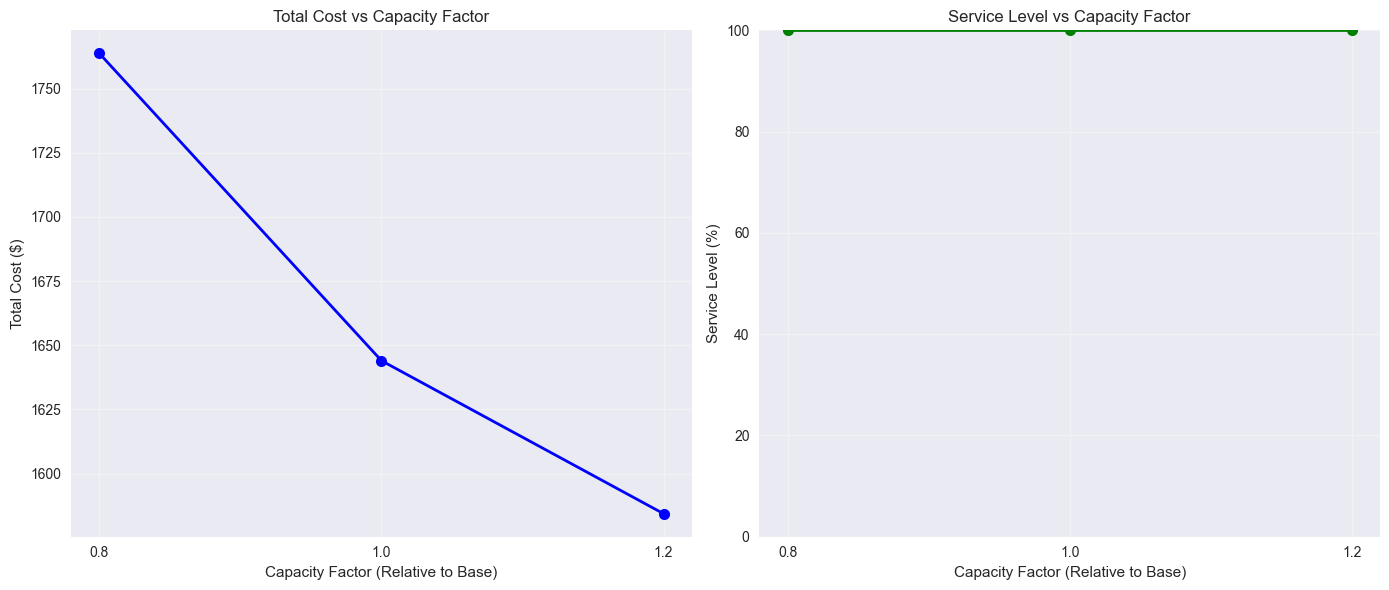

In [6]:
def sensitivity_analysis(problem):
    """Perform sensitivity analysis on key parameters"""
    
    print("=" * 60)
    print("SENSITIVITY ANALYSIS")
    print("=" * 60)
    
    # Test different capacity scenarios
    capacity_scenarios = [0.8, 1.0, 1.2]  # 80%, 100%, 120% of base capacity
    
    results_comparison = []
    
    for scenario in capacity_scenarios:
        # Create modified problem
        modified_problem = KittingProblem(
            num_skus=problem.num_skus,
            num_kits=problem.num_kits,
            num_shifts=problem.num_shifts,
            num_periods=problem.num_periods,
            demand=problem.demand.copy(),
            processing_time=problem.processing_time.copy(),
            holding_cost_sku=problem.holding_cost_sku.copy(),
            holding_cost_kit=problem.holding_cost_kit.copy(),
            labor_cost=problem.labor_cost.copy(),
            capacity=problem.capacity * scenario,  # Modify capacity
            bill_of_materials=problem.bill_of_materials.copy(),
            shortage_penalty=problem.shortage_penalty,
            storage_capacity=problem.storage_capacity
        )
        
        # Solve modified problem
        try:
            scenario_results, _ = solve_kitting_mip(modified_problem)
            
            # Calculate key metrics
            total_demand = np.sum(modified_problem.demand)
            total_shortage = np.sum(scenario_results['shortages'])
            service_level = ((total_demand - total_shortage) / total_demand) * 100
            
            results_comparison.append({
                'capacity_factor': scenario,
                'total_cost': scenario_results['objective'],
                'service_level': service_level,
                'total_production': np.sum(scenario_results['production_schedule'])
            })
            
        except Exception as e:
            print(f"Could not solve scenario {scenario}: {e}")
    
    # Display comparison
    print("\nCapacity Scenario Comparison:")
    print("-" * 50)
    print(f"{'Capacity':<12} {'Total Cost':<12} {'Service Level':<14} {'Total Production':<16}")
    print("-" * 50)
    
    for result in results_comparison:
        print(f"{result['capacity_factor']:<12.1f} ${result['total_cost']:<11.2f} {result['service_level']:<13.1f}% {result['total_production']:<15.1f}")
    
    # Visualize sensitivity analysis
    if len(results_comparison) > 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        capacities = [r['capacity_factor'] for r in results_comparison]
        costs = [r['total_cost'] for r in results_comparison]
        service_levels = [r['service_level'] for r in results_comparison]
        
        # Cost vs Capacity
        ax1.plot(capacities, costs, 'bo-', linewidth=2, markersize=8)
        ax1.set_title('Total Cost vs Capacity Factor')
        ax1.set_xlabel('Capacity Factor (Relative to Base)')
        ax1.set_ylabel('Total Cost ($)')
        ax1.grid(True, alpha=0.3)
        ax1.set_xticks(capacities)
        
        # Service Level vs Capacity
        ax2.plot(capacities, service_levels, 'go-', linewidth=2, markersize=8)
        ax2.set_title('Service Level vs Capacity Factor')
        ax2.set_xlabel('Capacity Factor (Relative to Base)')
        ax2.set_ylabel('Service Level (%)')
        ax2.grid(True, alpha=0.3)
        ax2.set_xticks(capacities)
        ax2.set_ylim(0, 100)
        
        plt.tight_layout()
        plt.show()
    
    return results_comparison

# Perform sensitivity analysis
sensitivity_results = sensitivity_analysis(problem)

### Why This Tier Exists vs Earlier Tiers

**Tier 1: Mathematical Foundation** - This tier provides the exact optimization baseline with provable optimality. It establishes the theoretical best achievable solution against which all other methods can be compared.

**Key Advantages:**
- **Guaranteed Optimality**: Finds the mathematically optimal solution
- **Comprehensive Modeling**: Handles all constraints and objectives simultaneously
- **Benchmark Standard**: Provides reference point for heuristic evaluation
- **Sensitivity Analysis**: Enables systematic parameter impact analysis

**Limitations:**
- **Computational Complexity**: May struggle with large problem instances
- **Data Requirements**: Needs complete, accurate parameter data
- **Static Assumptions**: Assumes deterministic demand and parameters

### When to Use This Tier

**Use Mathematical Formulation when:**
- Problem size is moderate (up to ~50 decision variables)
- Optimal solution is required for critical decisions
- Complete and accurate data is available
- Computational time is not a critical constraint
- You need a benchmark for evaluating other methods

**Ideal Applications:**
- Strategic planning decisions with high-value impact
- Contract negotiations requiring optimal cost analysis
- System design and capacity planning studies
- Academic research and algorithm validation

### Pros/Cons Summary

| Aspect | Advantage | Disadvantage |
|--------|-----------|--------------|
| **Solution Quality** | Guaranteed optimal | May be computationally intensive |
| **Modeling Power** | Handles complex constraints | Requires precise mathematical formulation |
| **Data Needs** | Uses all available information | Sensitive to data quality |
| **Speed** | Fast for small/medium problems | Slower for large instances |
| **Interpretability** | Clear objective and constraints | Complex mathematical notation |

This mathematical formulation tier establishes the foundation for understanding the kitting optimization problem and provides the optimal baseline against which all subsequent tiers will be compared.